In [15]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [21]:
env = gym.make('FrozenLake-v1', map_name = '4x4', is_slippery = False, render_mode = 'rgb_array')
q_table = np.zeros(shape=(env.observation_space.n, env.action_space.n))
rewards_per_episode = []
epsilon_decay_graph = []

In [22]:
learning_rate = 0.9 # alpha
discount_factor = 0.9 # gamma
epsilon = 0.9 # random actions
epsilon_decay_rate = 0.001
n_episodes = 1000

In [23]:
for i in range(n_episodes):
    state = env.reset()[0] # Generates a new starting state

    terminated, truncated = False, False

    accumulated_reward = 0
    while (not terminated and not truncated):
        
        if (np.random.random() < epsilon): # Exploaratory action 90% of the time
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        new_state, reward, terminated, truncated, info = env.step(action)
        
        if terminated == True:
            q_table[state][action] += learning_rate * ((reward + discount_factor * 0) - q_table[state][action])
        else: 
            q_table[state][action] += learning_rate * ((reward + discount_factor * np.max(q_table[new_state])) - q_table[state][action])
        accumulated_reward += reward
        state = new_state
    rewards_per_episode.append(accumulated_reward)
    epsilon = max(epsilon - epsilon_decay_rate, 0.1)
    epsilon_decay_graph.append(epsilon)
env.close()

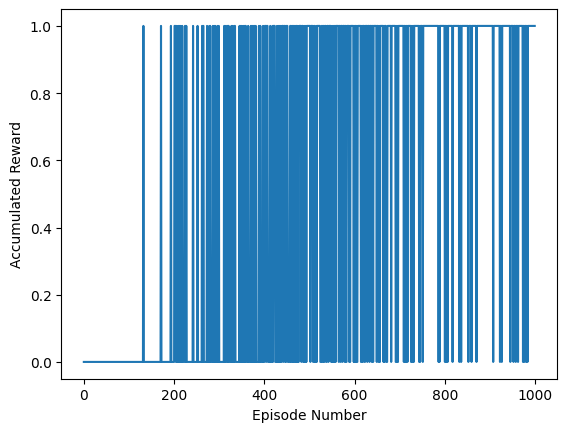

In [24]:
plt.plot(range(n_episodes), rewards_per_episode)
plt.xlabel('Episode Number')
plt.ylabel('Accumulated Reward')
plt.show()

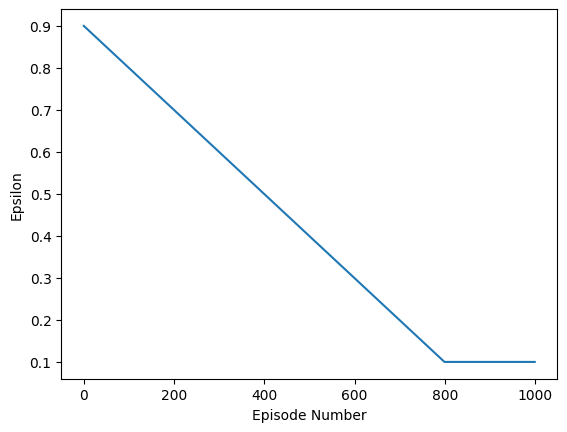

In [25]:
plt.plot(range(n_episodes), epsilon_decay_graph)
plt.xlabel('Episode Number')
plt.ylabel('Epsilon')
plt.show()